<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# EPC Dataset Analysis Using BIRCH, Mini-Batch K-Means and K-Prototypes

### Real-World Applications

| Application                              | Practical Use                                                                                                                          | Potential Benefit                                                                         |
| ---------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| **Energy Efficiency Grants & Subsidies** | Identify high-consumption and low-efficiency property clusters to target retrofit grants, insulation schemes, and heat-pump subsidies. | More effective use of public funding and improved energy efficiency.                      |
| **Energy Cost & Vulnerability Mapping**  | Identify clusters with high heating, lighting, and hot-water costs, particularly relative to property size.                            | Supports early identification of potential fuel-poverty risks and targeted support.       |
| **Real Estate Decarbonisation**          | Segment large property portfolios and prioritise buildings for energy-efficiency upgrades.                                             | Helps maximise carbon reduction and optimise capital investment.                          |
| **Targeted Clean Energy Services**       | Match cluster characteristics with suitable solutions such as solar panels, smart thermostats, or other energy technologies.           | Enables more targeted services and potentially faster financial payback.                  |
| **Urban Infrastructure & Grid Planning** | Combine cluster distributions with spatial information to estimate local energy-demand patterns.                                       | Supports electricity/gas network upgrades, district heating, and infrastructure planning. |


## Pipeline overview
| Stage                          | Summary                                                                                                                          | Key Details                                                                                                                                                                |
| ------------------------------ | -------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1. Algorithm Selection**     | Compared clustering algorithms and selected **BIRCH**.                                                                           | Compared **BIRCH, Mini-Batch K-Means, K-Prototypes** based on scalability, data types, complexity, outlier handling, geometry assumptions, and hyperparameter sensitivity. |
| **2. Data Loading**            | Loaded the Sheffield EPC dataset.                                                                                                | `EPC_Sheffield_20260414-clean.csv` — **209,230 records, 25 columns**                                                                                                       |
| **3. Data Cleaning**           | Removed identifier and metadata columns.                                                                                         | Dropped `certificate_number`, `postcode`, `constituency_label`, `constituency`                                                                                             |
| **4. Feature Selection**       | Selected six numerical energy and cost variables.                                                                                | `energy_consumption_current`, `total_floor_area`, `current_energy_efficiency`, `heating_cost_current`, `hot_water_cost_current`, `lighting_cost_current`                   |
| **5. Missing Value Treatment** | Filled missing numerical values using median imputation.                                                                         | `SimpleImputer(strategy="median")`                                                                                                                                         |
| **6. Feature Scaling**         | Scaled features to reduce the effect of extreme values.                                                                          | `RobustScaler`                                                                                                                                                             |
| **7. BIRCH Training**          | Applied BIRCH clustering to the full dataset.                                                                                    | `threshold=0.5`, `branching_factor=50`, `n_clusters=4`                                                                                                                     |
| **8. Cluster Assignment**      | Generated four cluster assignments for all observations.                                                                         | **4 clusters** across **209,230 properties**                                                                                                                               |
| **9. Cluster Ranking**         | Ordered clusters according to mean energy consumption.                                                                           | Renamed sequentially as **Cluster 1–4**                                                                                                                                    |
| **10. Cluster Profiling**      | Summarised characteristics of each cluster.                                                                                      | Calculated **count, mean, median**, and **percentage cluster size**                                                                                                        |
| **11. Visualisation**          | Visualised differences between cluster profiles.                                                                                 | Distribution plots used to compare feature patterns across clusters                                                                                                        |
| **Overall Outcome**            | Identified and profiled four groups of properties based on energy consumption, efficiency, floor area, and energy-related costs. | Provides a basis for interpreting **energy-performance patterns across Sheffield properties**                                                                              |


### Algorithm Comparison

| **Feature / Dimension**        | **BIRCH**                                                                                  | **Mini-Batch K-Means**                                                              | **K-Prototypes**                                                                                             |
| ------------------------------ | ------------------------------------------------------------------------------------------ | ----------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------ |
| **Algorithmic Class**          | Hierarchical / Tree-based stream clustering                                                | Partitioning / Centroid-based iterative clustering                                  | Hybrid Partitioning / Prototype-based (K-Means + K-Modes)                                                    |
| **Data Types Supported**       | Continuous numerical                                                                       | Continuous numerical                                                                | Mixed (Continuous numerical and Nominal categorical)                                                         |
| **Categorical Support**        | **Indirect** (requires transformation like One-Hot Encoding)                               | **Indirect** (requires transformation like One-Hot Encoding)                        | **Direct / Native** (uses simple matching dissimilarity metric)                                              |
| **Time Complexity**            | $\mathcal{O}(N \cdot d \cdot L)$ (Linear $\mathcal{O}(N)$ tree construction)               | $\mathcal{O}(N \cdot K \cdot d)$ (Reduced constant factor via batch size $b \ll N$) | $\mathcal{O}(N \cdot K \cdot d \cdot i)$ ($i$ iterations over mixed metrics)                                 |
| **Space Complexity**           | $\mathcal{O}(N_{\text{subclusters}} \cdot d)$ (Bounded by Clustering Feature tree size)   | $\mathcal{O}(K \cdot d + b \cdot d)$ (Centroids and batch storage in memory)        | $\mathcal{O}(N \cdot d + K \cdot d)$ (Full data matrix and prototypes in memory)                             |
| **Scalability Limit**          | Scales to millions of rows; limited by feature dimensionality ($d$) and RAM for tree nodes | Highly scalable to tens of millions of rows (out-of-core streaming capable)         | Moderate scale ($N \approx 10^4 - 10^5$); bottlenecked by iterative distance calculations across mixed types |
| **Outlier Handling**           | **Good** (treats sparse subclusters/leaf nodes as noise in Phase 3)                        | **Poor** (centroids pulled by extreme values, though mini-batch dampens impact)     | **Poor** (mean and mode prototype updates remain sensitive to extreme values)                                |
| **Geometry Assumption**        | Spherical / Convex subclusters (Euclidean metric)                                          | Spherical / Convex clusters of equal size/variance (Voronoi partitions)             | Spherical in numeric space; hyper-rectangular/matching in categorical space                                  |
| **Hyperparameter Sensitivity** | **High**: Sensitive to `threshold` (cluster radius) and `branching_factor`                 | **Moderate to High**: Sensitive to $K$ (number of clusters) and `batch_size`        | **High**: Sensitive to $K$ and $\gamma$ (weight balancing numerical vs. categorical dissimilarity)           |

# BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import Birch
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

# ==========================================
# STEP A: IMPORT & PREPARE DATA (BIRCH)
# ==========================================

# Load dataset
df = pd.read_csv('EPC_Sheffield_20260414-clean.csv')

# Drop the specified 4 columns
cols_to_drop = ['certificate_number', 'postcode', 'constituency_label', 'constituency']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Data shape:", df.shape)

# Core numeric features for energy consumption profiling
features = [
    'energy_consumption_current', 
    'total_floor_area', 
    'current_energy_efficiency', 
    'heating_cost_current', 
    'hot_water_cost_current',
    'lighting_cost_current'
]

# Impute and Scale
imputer = SimpleImputer(strategy='median')
scaler = RobustScaler()

X_imp = imputer.fit_transform(df[features])
X_scaled = scaler.fit_transform(X_imp)

# Fit BIRCH on full dataset (209,230 rows)
# threshold controls radius of leaf subclusters; n_clusters=4 for global clustering
birch_model = Birch(threshold=0.5, branching_factor=50, n_clusters=4)
df['birch_cluster'] = birch_model.fit_predict(X_scaled)

# Order clusters by average energy consumption
cluster_order = df.groupby('birch_cluster')['energy_consumption_current'].mean().sort_values().index
rank_map = {old_c: f"Cluster {i+1}" for i, old_c in enumerate(cluster_order)}
df['cluster_label'] = df['birch_cluster'].map(rank_map)

# Summary statistics
summary = df.groupby('cluster_label')[features].agg(['count', 'mean', 'median']).round(2)
print("\nBIRCH Clustering Summary across full 209,230 dataset:")
print(summary)

# Distribution percentages
pcts = (df['cluster_label'].value_counts(normalize=True).sort_index() * 100).round(2)
print("\nCluster Sizes (%):")
print(pcts)

Data shape: (209230, 25)

BIRCH Clustering Summary across full 209,230 dataset:
              energy_consumption_current                total_floor_area  \
                                   count    mean median            count   
cluster_label                                                              
Cluster 1                         198393  243.59  234.0           198393   
Cluster 2                           2375  251.98  253.0             2375   
Cluster 3                            106  357.49  298.5              106   
Cluster 4                           8356  532.75  507.0             8356   

                             current_energy_efficiency                \
                 mean median                     count   mean median   
cluster_label                                                          
Cluster 1       78.25   75.0                    198393  66.68   68.0   
Cluster 2      270.26  248.0                      2375  59.06   59.0   
Cluster 3      728.75  570.

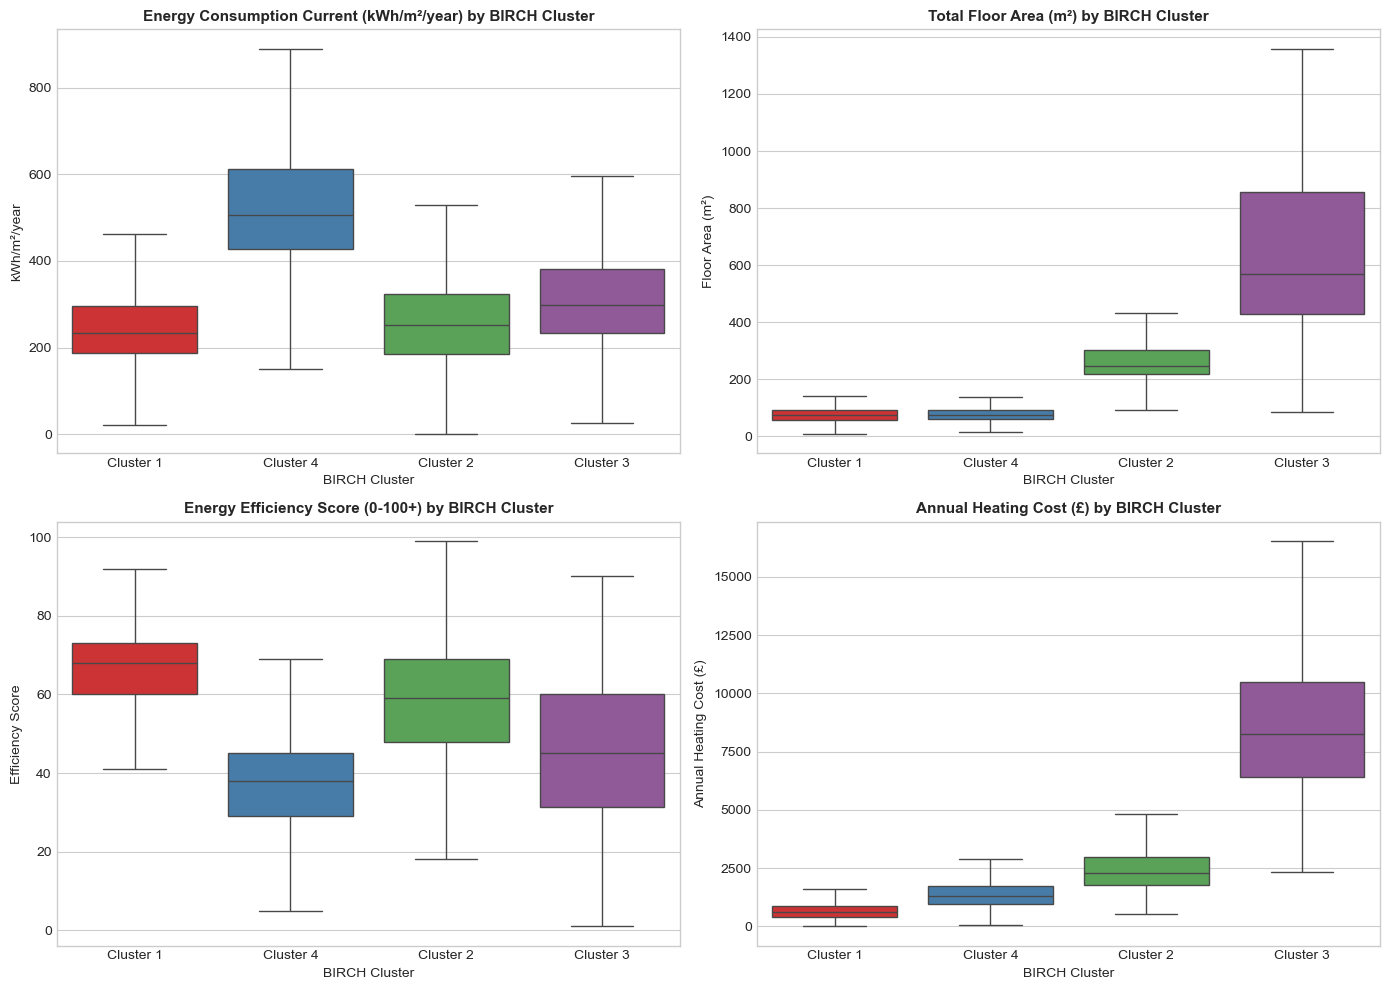

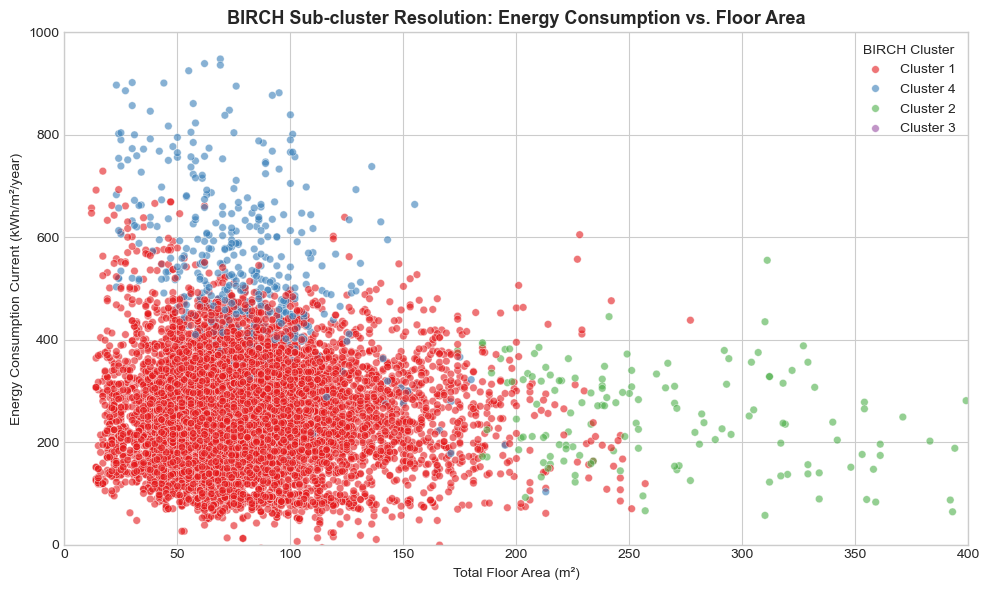

BIRCH plots created successfully.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP B: VISUALISATION (BIRCH)
# ==========================================

# Generate visualizations for BIRCH results
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
palette = sns.color_palette("Set1", 4)

# 1. Energy Consumption Boxplot
sns.boxplot(
    data=df,
    x='cluster_label',
    y='energy_consumption_current',
    ax=axes[0, 0],
    hue='cluster_label',
    palette=palette,
    legend=False,
    showfliers=False,
)
axes[0, 0].set_title(
    'Energy Consumption Current (kWh/m²/year) by BIRCH Cluster',
    fontsize=11,
    fontweight='bold',
)
axes[0, 0].set_xlabel('BIRCH Cluster')
axes[0, 0].set_ylabel('kWh/m²/year')

# 2. Total Floor Area Boxplot
sns.boxplot(
    data=df,
    x='cluster_label',
    y='total_floor_area',
    ax=axes[0, 1],
    hue='cluster_label',
    palette=palette,
    legend=False,
    showfliers=False,
)
axes[0, 1].set_title(
    'Total Floor Area (m²) by BIRCH Cluster', fontsize=11, fontweight='bold'
)
axes[0, 1].set_xlabel('BIRCH Cluster')
axes[0, 1].set_ylabel('Floor Area (m²)')

# 3. Energy Efficiency Score Boxplot
sns.boxplot(
    data=df,
    x='cluster_label',
    y='current_energy_efficiency',
    ax=axes[1, 0],
    hue='cluster_label',
    palette=palette,
    legend=False,
    showfliers=False,
)
axes[1, 0].set_title(
    'Energy Efficiency Score (0-100+) by BIRCH Cluster',
    fontsize=11,
    fontweight='bold',
)
axes[1, 0].set_xlabel('BIRCH Cluster')
axes[1, 0].set_ylabel('Efficiency Score')

# 4. Heating Cost Boxplot
sns.boxplot(
    data=df,
    x='cluster_label',
    y='heating_cost_current',
    ax=axes[1, 1],
    hue='cluster_label',
    palette=palette,
    legend=False,
    showfliers=False,
)
axes[1, 1].set_title(
    'Annual Heating Cost (£) by BIRCH Cluster', fontsize=11, fontweight='bold'
)
axes[1, 1].set_xlabel('BIRCH Cluster')
axes[1, 1].set_ylabel('Annual Heating Cost (£)')

plt.tight_layout()
plt.show()
# plt.savefig('birch_cluster_profiles.png', dpi=300)
# plt.close()

# Scatter plot of Floor Area vs Energy Consumption for BIRCH clusters
plt.figure(figsize=(10, 6))
sample_birch = df.sample(n=12000, random_state=42)
sns.scatterplot(
    data=sample_birch,
    x='total_floor_area',
    y='energy_consumption_current',
    hue='cluster_label',
    palette=palette,
    alpha=0.6,
    s=30,
)
plt.xlim(0, 400)
plt.ylim(0, 1000)
plt.title(
    'BIRCH Sub-cluster Resolution: Energy Consumption vs. Floor Area',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Total Floor Area (m²)')
plt.ylabel('Energy Consumption Current (kWh/m²/year)')
plt.legend(title='BIRCH Cluster')
plt.tight_layout()
plt.show()

# plt.savefig('birch_scatter.png', dpi=300)
# plt.close()

print("BIRCH plots created successfully.")

# Mini-Batch K-Means for rapid execution

In [3]:
# ====================================================
# STEP A: IMPORT & PREPARE DATA (Mini-Batch K-Means)
# ====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load data
df = pd.read_csv('EPC_Sheffield_20260414-clean.csv')

# Drop the specified 4 columns
cols_to_drop = ['certificate_number', 'postcode', 'constituency_label', 'constituency']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Shape:", df.shape)

# Let's inspect kmodes availability
try:
    from kmodes.kprototypes import KPrototypes
    print("kmodes is installed!")
    kmodes_installed = True
except ImportError:
    print("kmodes is not installed.")
    kmodes_installed = False

Shape: (209230, 25)
kmodes is installed!


Preprocessed feature matrix shape: (209230, 49)
k=2, inertia=8133966.07
k=3, inertia=4267597.76
k=4, inertia=3153572.56
k=5, inertia=2818383.11
k=6, inertia=2354311.14
k=7, inertia=2209031.39
k=8, inertia=1970450.33


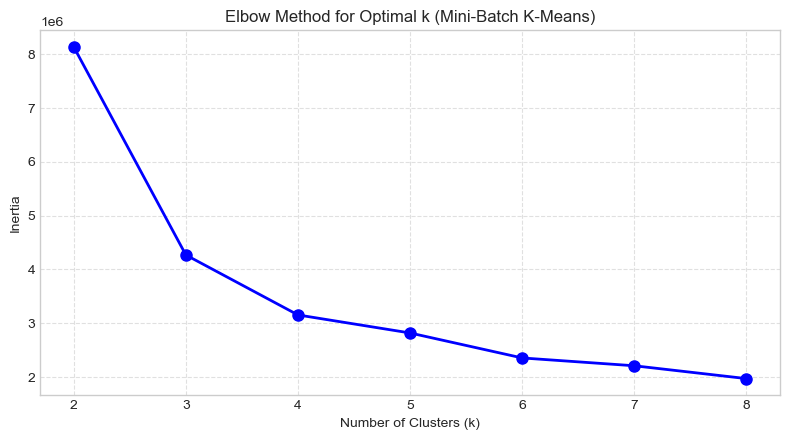

In [4]:
# Select key features for clustering
# Numeric features
num_features = [
    'energy_consumption_current', 
    'total_floor_area', 
    'current_energy_efficiency', 
    'heating_cost_current', 
    'hot_water_cost_current', 
    'lighting_cost_current',
    'number_habitable_rooms',
    'multi_glaze_proportion'
]

# Categorical features
cat_features = [
    'property_type',
    'built_form',
    'construction_age_band',
    'current_energy_rating'
]

# Clean up/preprocess pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

# Fit-transform features
X_prep = preprocessor.fit_transform(df)
print("Preprocessed feature matrix shape:", X_prep.shape)

# Find optimal K using inertia over range k=2 to k=8
inertias = []
k_range = range(2, 9)
for k in k_range:
    mbk = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=4096, n_init=5)
    mbk.fit(X_prep)
    inertias.append(mbk.inertia_)
    print(f"k={k}, inertia={mbk.inertia_:.2f}")

# Plot elbow curve
plt.figure(figsize=(8, 4.5))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method for Optimal k (Mini-Batch K-Means)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
# plt.savefig('elbow_curve.png', dpi=300)
# plt.close()

In [5]:
# Fit model with optimal k=4
optimal_k = 4
mbk = MiniBatchKMeans(n_clusters=optimal_k, random_state=42, batch_size=4096, n_init=10)
df['cluster'] = mbk.fit_predict(X_prep)

# Label clusters intuitively based on energy consumption rank/character
cluster_means = df.groupby('cluster')['energy_consumption_current'].mean().sort_values()
rank_map = {old_c: f"Cluster {i+1}" for i, old_c in enumerate(cluster_means.index)}
df['cluster_label'] = df['cluster'].map(rank_map)

# Compute detailed summary stats for each cluster
summary_cols = [
    'energy_consumption_current', 'total_floor_area', 'current_energy_efficiency',
    'heating_cost_current', 'hot_water_cost_current', 'lighting_cost_current',
    'number_habitable_rooms', 'multi_glaze_proportion'
]

cluster_summary = df.groupby('cluster_label')[summary_cols].agg(['mean', 'median', 'std'])
print(cluster_summary)

# Count and percentage per cluster
counts = df['cluster_label'].value_counts().sort_index()
percentages = (counts / len(df) * 100).round(2)
counts_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
print("\nCluster Sizes:")
print(counts_df)

# Top Property Types per Cluster
print("\nTop Property Type per Cluster:")
print(df.groupby('cluster_label')['property_type'].value_counts(normalize=True).groupby(level=0).head(2))

# Energy Rating Distribution per Cluster
print("\nMost Common Energy Ratings per Cluster:")
print(df.groupby('cluster_label')['current_energy_rating'].value_counts(normalize=True).groupby(level=0).head(2))

              energy_consumption_current                    total_floor_area  \
                                    mean median         std             mean   
cluster_label                                                                  
Cluster 1                     248.711418  233.0  111.437704        79.310774   
Cluster 2                     332.916757  316.0  113.998547       103.306742   
Cluster 3                     354.901961  334.0  121.068517       111.318083   
Cluster 4                     371.800106  340.0  151.505250        97.626393   

                                current_energy_efficiency                    \
              median        std                      mean median        std   
cluster_label                                                                 
Cluster 1       74.0  40.585433                 66.260374   68.0  11.780069   
Cluster 2       89.0  50.424351                 54.039020   56.0  12.826406   
Cluster 3       93.0  63.165686             

In [6]:
# Core numeric features for building energy performance
core_features = [
    'energy_consumption_current', 
    'total_floor_area', 
    'current_energy_efficiency', 
    'heating_cost_current', 
    'hot_water_cost_current',
    'lighting_cost_current'
]

scaler_core = RobustScaler()
X_core = scaler_core.fit_transform(df[core_features].fillna(df[core_features].median()))

# Fit MiniBatchKMeans with k=4
mbk_core = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=4096, n_init=10)
df['cluster_num'] = mbk_core.fit_predict(X_core)

# Order clusters by mean energy consumption
mean_energy = df.groupby('cluster_num')['energy_consumption_current'].mean().sort_values()
rank_num_map = {old_c: f"Cluster {i+1}" for i, old_c in enumerate(mean_energy.index)}
df['energy_cluster'] = df['cluster_num'].map(rank_num_map)

# Summary of the 4 numeric-driven clusters
num_summary = df.groupby('energy_cluster')[core_features].agg(['count', 'mean', 'median']).round(2)
print("Numeric-driven Cluster Summary:")
print(num_summary)

print("\nCluster Sizes:")
print(df['energy_cluster'].value_counts(normalize=True).sort_index() * 100)

Numeric-driven Cluster Summary:
               energy_consumption_current                total_floor_area  \
                                    count    mean median            count   
energy_cluster                                                              
Cluster 1                          155188  223.24  221.0           155188   
Cluster 2                           17290  260.15  260.0            17290   
Cluster 3                            9775  276.74  251.0             9775   
Cluster 4                           26977  428.81  396.0            26977   

                              current_energy_efficiency                \
                  mean median                     count   mean median   
energy_cluster                                                          
Cluster 1        70.51   70.0                    155188  69.62   69.0   
Cluster 2       171.32  155.0                     17290  60.03   60.0   
Cluster 3        71.08   69.0                      9775  62.36 

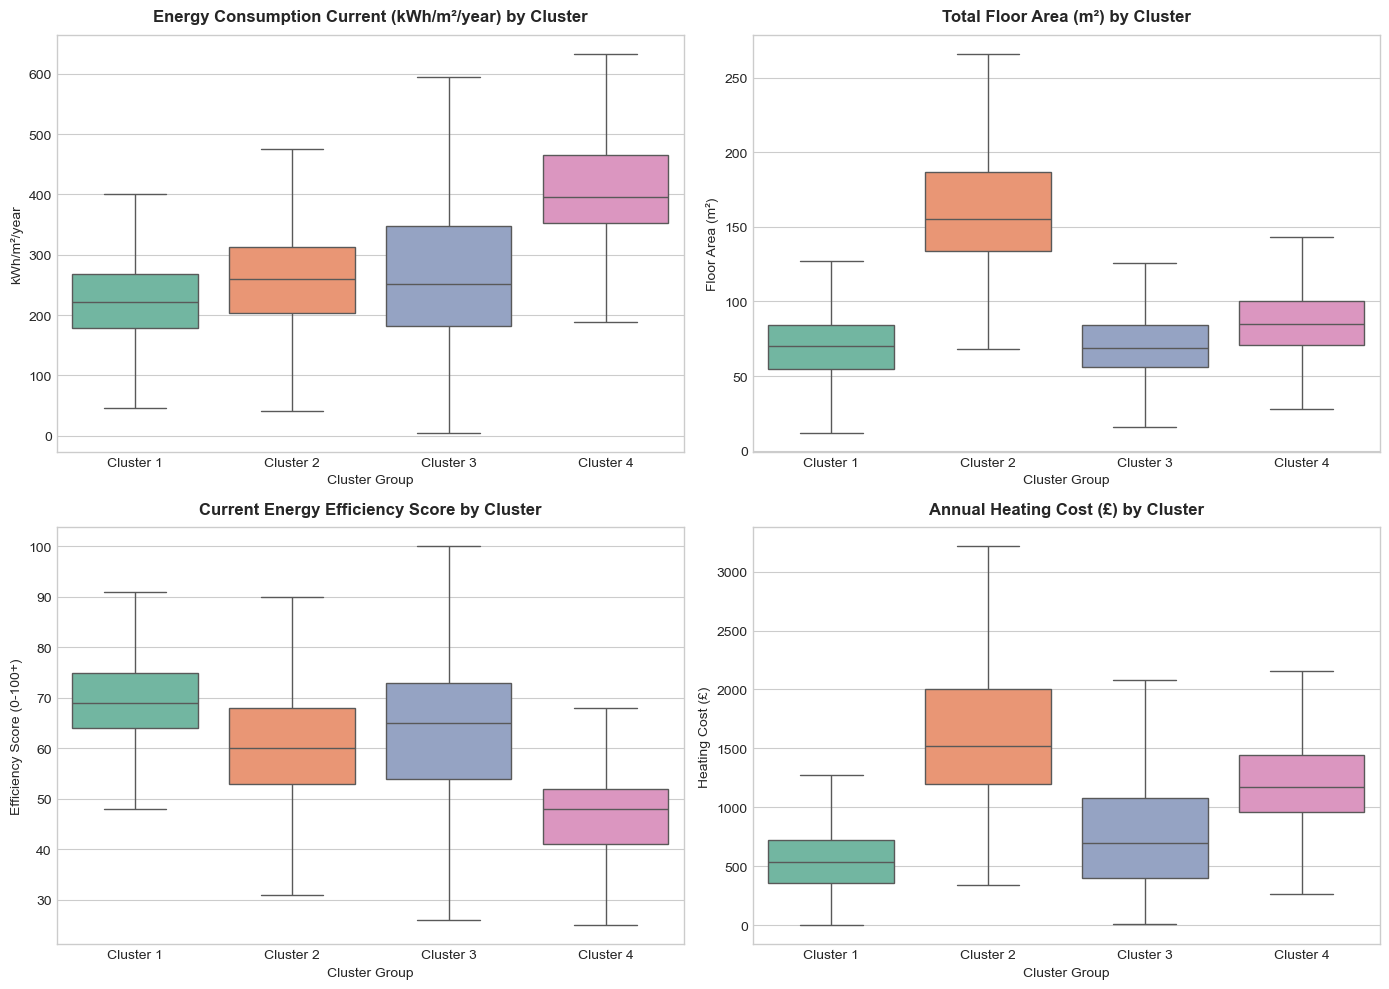

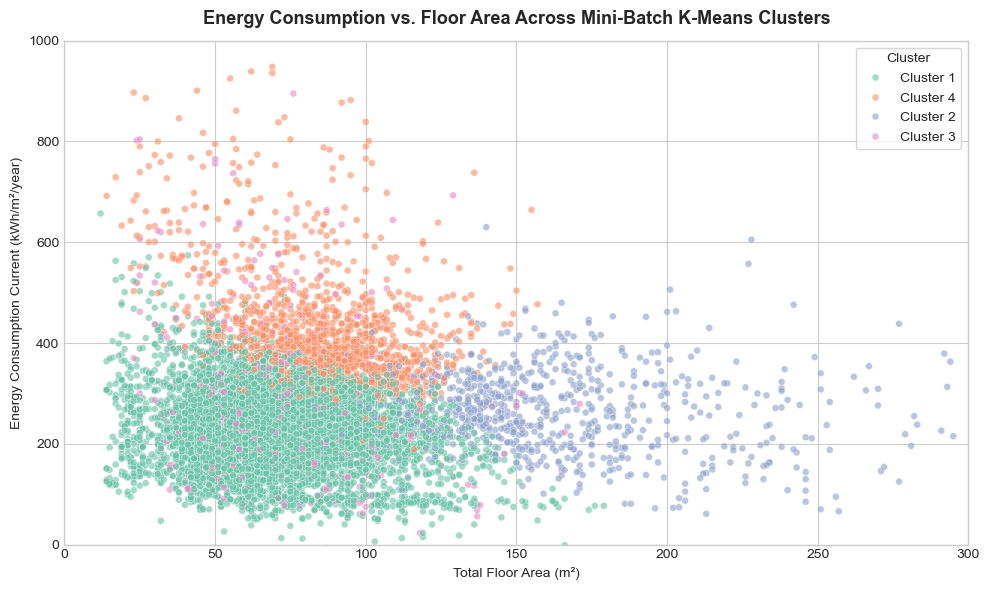

Mini-BIRCH plots created successfully.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
palette = sns.color_palette('Set2', 4)

# Define configurations for the 2x2 grid to eliminate repetitive code
grid_configs = [
    {
        'y': 'energy_consumption_current',
        'title': 'Energy Consumption Current (kWh/m²/year) by Cluster',
        'ylabel': 'kWh/m²/year',
    },
    {
        'y': 'total_floor_area',
        'title': 'Total Floor Area (m²) by Cluster',
        'ylabel': 'Floor Area (m²)',
    },
    {
        'y': 'current_energy_efficiency',
        'title': 'Current Energy Efficiency Score by Cluster',
        'ylabel': 'Efficiency Score (0-100+)',
    },
    {
        'y': 'heating_cost_current',
        'title': 'Annual Heating Cost (£) by Cluster',
        'ylabel': 'Heating Cost (£)',
    },
]

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for config, ax in zip(grid_configs, axes.flat):
    sns.boxplot(
        data=df,
        x='energy_cluster',
        y=config['y'],
        hue='energy_cluster',  # Fixes Seaborn v0.13+ deprecation warning
        legend=False,
        palette=palette,
        showfliers=False,
        ax=ax,
    )
    ax.set_title(config['title'], fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Cluster Group', fontsize=10)
    ax.set_ylabel(config['ylabel'], fontsize=10)

plt.tight_layout()
plt.show()
# plt.savefig('cluster_profiles.png', dpi=300, bbox_inches='tight')
# plt.close()

# -------------------------------------------------------------------------
# Chart 2: Energy Consumption vs Floor Area colored by Cluster
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Safely handle sampling if df has fewer than 10,000 rows
n_samples = min(len(df), 10000)
sample_df = (
    df.sample(n=n_samples, random_state=42) if len(df) > n_samples else df
)

sns.scatterplot(
    data=sample_df,
    x='total_floor_area',
    y='energy_consumption_current',
    hue='energy_cluster',
    alpha=0.6,
    palette=palette,
    s=25,
)

plt.xlim(0, 300)
plt.ylim(0, 1000)
plt.title(
    'Energy Consumption vs. Floor Area Across Mini-Batch K-Means Clusters',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Total Floor Area (m²)', fontsize=10)
plt.ylabel('Energy Consumption Current (kWh/m²/year)', fontsize=10)
plt.legend(title='Cluster', frameon=True)
plt.tight_layout()
plt.show()
# plt.savefig('scatter_clusters.png', dpi=300, bbox_inches='tight')
# plt.close()

print('Mini-BIRCH plots created successfully.')

# K- prototype

--- K-Prototypes Profile: energy_consumption_current ---
                count        mean         std  median    IQR
kproto_cluster                                              
0                4651  225.186627   67.171823   228.0   79.0
1                2877  220.572124   94.031814   206.0  104.0
2                1614  411.664188  120.740185   383.0  109.0
3                 858  251.836830   80.188890   248.0  109.0


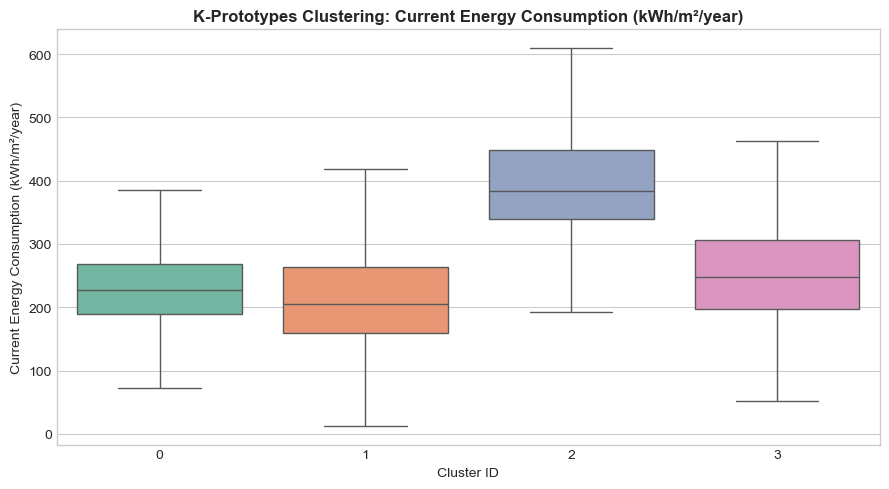

In [8]:
# ================================================
# STEP A: IMPORT & PREPARE DATA (K-prototype)
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('EPC_Sheffield_20260414-clean.csv')

# Drop specified 4 columns
drop_cols = ['certificate_number', 'postcode', 'constituency_label', 'constituency']
df_clean = df.drop(columns=drop_cols).copy()

# Categorize columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Impute missing values
df_clean[num_cols] = SimpleImputer(strategy='median').fit_transform(df_clean[num_cols])
df_clean[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df_clean[cat_cols])

# Standardize numerical features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df_clean[num_cols])
X_cat_raw = df_clean[cat_cols].astype(str).values

# K-PROTOTYPES ALGORITHM
def run_k_prototypes(X_num, X_cat, n_clusters=4, gamma=0.5, max_iter=20, random_state=42):
    np.random.seed(random_state)
    n_samples, n_num = X_num.shape
    _, n_cat = X_cat.shape
    
    # Initialize prototypes
    init_indices = np.random.choice(n_samples, size=n_clusters, replace=False)
    proto_num = X_num[init_indices].copy()
    proto_cat = X_cat[init_indices].copy()
    
    labels = np.zeros(n_samples, dtype=int)
    
    for it in range(max_iter):
        # Calculate numeric and categorical distances
        num_dists = np.sum((X_num[:, np.newaxis, :] - proto_num[np.newaxis, :, :]) ** 2, axis=2)
        cat_dists = np.sum(X_cat[:, np.newaxis, :] != proto_cat[np.newaxis, :, :], axis=2)
        total_dists = num_dists + gamma * cat_dists
        
        # Assign clusters
        new_labels = np.argmin(total_dists, axis=1)
        if np.array_equal(labels, new_labels) and it > 0:
            break
        labels = new_labels
        
        # Update prototypes (num -> mean, cat -> mode)
        for k in range(n_clusters):
            mask = (labels == k)
            if np.sum(mask) > 0:
                proto_num[k] = np.mean(X_num[mask], axis=0)
                for j in range(n_cat):
                    vals, counts = np.unique(X_cat[mask, j], return_counts=True)
                    proto_cat[k, j] = vals[np.argmax(counts)]
                    
    return labels, proto_num, proto_cat

# Run on sample
np.random.seed(42)
sample_idx = np.random.choice(len(df_clean), size=10000, replace=False)
df_sub = df_clean.iloc[sample_idx].copy().reset_index(drop=True)

labels, p_num, p_cat = run_k_prototypes(
    X_num_scaled[sample_idx], 
    X_cat_raw[sample_idx], 
    n_clusters=4, 
    gamma=0.5
)
df_sub['kproto_cluster'] = labels

# ==========================================
# STEP 5: PROFILING & VISUALIZATION
# ==========================================
stats = df_sub.groupby('kproto_cluster')['energy_consumption_current'].agg(
    ['count', 'mean', 'std', 'min', lambda x: x.quantile(0.25), 'median', lambda x: x.quantile(0.75), 'max']
).rename(columns={'<lambda_0>': '25%', '<lambda_1>': '75%'})
stats['IQR'] = stats['75%'] - stats['25%']

print("--- K-Prototypes Profile: energy_consumption_current ---")
print(stats[['count', 'mean', 'std', 'median', 'IQR']])

# Visualization
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_sub, 
    x='kproto_cluster', 
    y='energy_consumption_current', 
    hue='kproto_cluster',
    palette='Set2', 
    showfliers=False,
    legend=False
)
plt.title('K-Prototypes Clustering: Current Energy Consumption (kWh/m²/year)', fontsize=12, fontweight='bold')
plt.xlabel('Cluster ID')
plt.ylabel('Current Energy Consumption (kWh/m²/year)')
plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# STEP B: VISUALISATION (K-prototype)
# ==========================================

# Skip due to time budget.